# Project — 3-SAT as a Graph-Coloring Problem — **Solutions**

**Discrete Mathematics — Graphs, Trees & Binary Trees**

Instructor / reference version of the standalone 3-SAT project. Every cell runs top to bottom and every assertion passes. The notebook is **self-contained**: it re-defines the few Lab 1 helpers it needs, so it can be run without Lab 1.

**The reduction.** From a Boolean formula $\varphi$ in 3-CNF we build a graph $G_\varphi$ that is **3-colorable if and only if $\varphi$ is satisfiable**. Three colors stand for **T**rue, **F**alse and **B**ase.

* a **base triangle** `T – F – B` forces three distinct colors;
* a **variable triangle** `x – ~x – B` makes `x` and `~x` opposite truth values;
* an **OR gadget** `OR(u,v)` outputs F only when both inputs are F;
* a **clause** chains two OR gadgets and forces the output to T.

## Prerequisites — Lab 1 helpers (provided)

`add_edge` / `build_graph` / `num_edges` and the `networkx` drawing + checking helpers, copied from Lab 1.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

def add_vertex(G, v):
    if v not in G:
        G[v] = []

def add_edge(G, u, v):
    """Add the undirected edge {u, v} (and its endpoints if needed); no duplicates."""
    add_vertex(G, u)
    add_vertex(G, v)
    if v not in G[u]:
        G[u].append(v)
    if u not in G[v]:
        G[v].append(u)

def build_graph(vertices, edges):
    G = {}
    for v in vertices:
        add_vertex(G, v)
    for u, v in edges:
        add_edge(G, u, v)
    return G

def num_edges(G):
    """Number of edges (handshake lemma: half the degree sum)."""
    return sum(len(G[v]) for v in G) // 2

def to_nx(G):
    H = nx.Graph()
    H.add_nodes_from(G)
    for u in G:
        for v in G[u]:
            H.add_edge(u, v)
    return H

def draw_graph(G, coloring=None, pos=None, title=""):
    H = to_nx(G)
    if pos is None:
        pos = nx.spring_layout(H, seed=7)
    palette = ["#2a9d8f", "#e63946", "#457b9d", "#e9c46a", "#f4a261", "#9b5de5"]
    node_color = "#a8dadc" if coloring is None else [palette[coloring[v] % len(palette)] for v in H.nodes()]
    plt.figure(figsize=(6.5, 5.0))
    nx.draw(H, pos, with_labels=True, node_color=node_color,
            node_size=600, font_weight="bold", font_size=8, edge_color="#666666")
    plt.title(title)
    plt.show()

print("Setup OK — networkx", nx.__version__)

Setup OK — networkx 3.4.2


## Provided helper — literal negation

In [2]:
def neg(lit):
    """Negation of a literal: 'x' <-> '~x'."""
    return lit[1:] if lit.startswith("~") else "~" + lit

assert neg("x") == "~x" and neg("~x") == "x"
print("neg OK")

neg OK


## Task 1 — Build the SAT graph (solution)

`or_gadget(u, v, tag)` creates a fresh triangle `a – b – out` and wires `a – u`, `b – v` (5 edges), returning the output vertex. Each clause chains two gadgets and forces the final output to T by joining it to both `F` and `B`.

In [3]:
def build_sat_graph(formula):
    """Graph that is 3-colorable iff `formula` (a list of 3-literal clauses) is satisfiable."""
    G = {}
    # base triangle
    add_edge(G, "T", "F"); add_edge(G, "T", "B"); add_edge(G, "F", "B")

    # one triangle  x -- ~x -- B  per variable
    variables = {lit.lstrip("~") for clause in formula for lit in clause}
    for x in sorted(variables):
        add_edge(G, x, neg(x))
        add_edge(G, x, "B")
        add_edge(G, neg(x), "B")

    def or_gadget(u, v, tag):
        """Fresh triangle a-b-o plus wires a-u and b-v; return the output vertex."""
        a, b, out = tag + "a", tag + "b", tag + "o"
        add_edge(G, a, u)
        add_edge(G, b, v)
        add_edge(G, a, b)
        add_edge(G, a, out)
        add_edge(G, b, out)
        return out

    for i, (l1, l2, l3) in enumerate(formula):
        o1 = or_gadget(l1, l2, f"c{i}_1")
        o2 = or_gadget(o1, l3, f"c{i}_2")
        add_edge(G, o2, "F")        # force the clause output to be colored like T
        add_edge(G, o2, "B")
    return G

print("build_sat_graph defined")

build_sat_graph defined


## Task 2 — The 3-coloring solver (solution)

Backtracking over vertices ordered by decreasing degree: try each color a neighbor does not already use, recurse, undo on failure.

In [4]:
def three_color(G):
    """A proper 3-coloring of G as {vertex: 0,1,2}, or None if impossible."""
    nodes = sorted(G, key=lambda v: -len(G[v]))
    color = {}

    def backtrack(i):
        if i == len(nodes):
            return True
        v = nodes[i]
        for c in range(3):
            if all(color.get(u) != c for u in G[v]):
                color[v] = c
                if backtrack(i + 1):
                    return True
                del color[v]
        return False

    return color if backtrack(0) else None

print("three_color defined")

three_color defined


## Task 3 — Decode the assignment (solution)

A variable is **True** iff its vertex shares vertex `'T'`'s color. `evaluate` is the provided reference checker.

In [5]:
def decode(coloring, formula):
    """Truth assignment read off a 3-coloring: x is True iff color[x] == color['T']."""
    variables = {lit.lstrip("~") for clause in formula for lit in clause}
    return {x: coloring[x] == coloring["T"] for x in variables}

def evaluate(formula, assignment):
    """Truth value of the formula under the assignment."""
    def value(lit):
        return not assignment[lit[1:]] if lit.startswith("~") else assignment[lit]
    return all(any(value(lit) for lit in clause) for clause in formula)

print("decode / evaluate defined")

decode / evaluate defined


## Putting it together — the satisfiable test case

`PHI` is satisfiable, so a proper 3-coloring must exist and decode to a satisfying assignment.

SAT graph: 33 vertices, 60 edges
assignment read off the coloring: {'y': False, 'z': True, 'x': False}
Challenge ✔ — the coloring solved the formula!


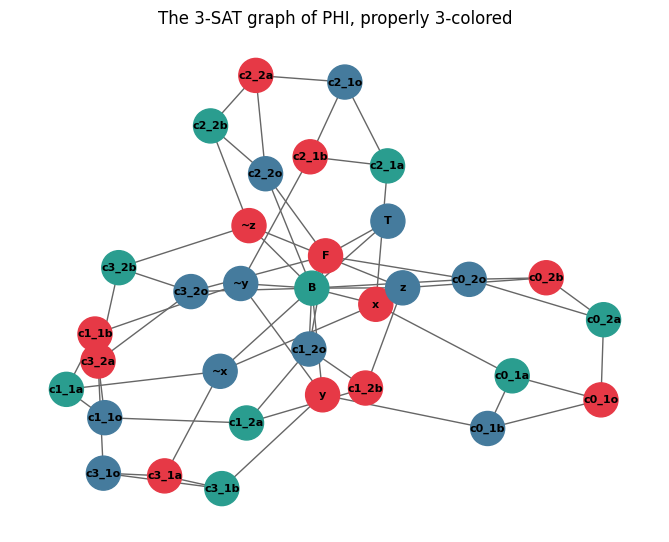

In [6]:
PHI = [("x", "y", "z"),
       ("~x", "~y", "z"),
       ("x", "~y", "~z"),
       ("~x", "y", "~z")]

G_sat = build_sat_graph(PHI)
print("SAT graph:", len(G_sat), "vertices,", num_edges(G_sat), "edges")

col = three_color(G_sat)
assert col is not None, "PHI is satisfiable, so a 3-coloring must exist"
assert all(col[u] != col[v] for u in G_sat for v in G_sat[u])   # proper

assignment = decode(col, PHI)
print("assignment read off the coloring:", assignment)
assert evaluate(PHI, assignment), "the decoded assignment must satisfy PHI"
print("Challenge \u2714 — the coloring solved the formula!")
draw_graph(G_sat, coloring=col, title="The 3-SAT graph of PHI, properly 3-colored")

## An unsatisfiable formula

`UNSAT` contains all 8 clauses on `x, y, z`, so every assignment falsifies one of them. Its graph must **not** be 3-colorable — `three_color` returns `None`.

In [7]:
UNSAT = [(a, b, c) for a in ("x", "~x") for b in ("y", "~y") for c in ("z", "~z")]
result = three_color(build_sat_graph(UNSAT))
print("three_color on UNSAT graph:", result)     # expected: None
assert result is None, "UNSAT formula must give a non-3-colorable graph"
print("Unsatisfiable case \u2714")

three_color on UNSAT graph: None
Unsatisfiable case ✔


## Verification 1 — a brute-force SAT solver as referee

We check the reduction independently: a small brute-force solver tries all $2^n$ assignments. For a batch of random 3-CNF formulas we confirm that **the graph is 3-colorable exactly when the formula is satisfiable**, and that whenever a coloring exists the decoded assignment really satisfies the formula.

In [8]:
import itertools, random

def brute_force_sat(formula):
    """True iff `formula` is satisfiable, by trying every assignment."""
    variables = sorted({lit.lstrip("~") for clause in formula for lit in clause})
    for bits in itertools.product([False, True], repeat=len(variables)):
        if evaluate(formula, dict(zip(variables, bits))):
            return True
    return False

def random_formula(n_vars, n_clauses, rng):
    vs = [chr(ord("a") + i) for i in range(n_vars)]
    clauses = []
    for _ in range(n_clauses):
        lits = tuple(("~" if rng.random() < 0.5 else "") + rng.choice(vs) for _ in range(3))
        clauses.append(lits)
    return clauses

rng = random.Random(2024)
agree = sat_count = 0
TRIALS = 200
for _ in range(TRIALS):
    phi = random_formula(rng.randint(2, 4), rng.randint(1, 6), rng)
    satisfiable = brute_force_sat(phi)
    sat_count += satisfiable
    col = three_color(build_sat_graph(phi))
    three_colorable = col is not None
    assert three_colorable == satisfiable, (phi, satisfiable, three_colorable)
    if col is not None:
        assert evaluate(phi, decode(col, phi))      # decoded assignment is correct
    agree += 1

print(f"{agree}/{TRIALS} random formulas: 3-colorability matched satisfiability")
print(f"   ({sat_count} were satisfiable, {TRIALS - sat_count} unsatisfiable)")
print("Verification 1 \u2714")

200/200 random formulas: 3-colorability matched satisfiability
   (199 were satisfiable, 1 unsatisfiable)
Verification 1 ✔


## Verification 2 — networkx as an independent coloring referee

For each random formula, `networkx` computes the **chromatic number** by brute force. The graph is 3-colorable iff that number is $\le 3$ — which must again match satisfiability.

In [9]:
def chromatic_number(H):
    """Exact chromatic number of a small networkx graph (brute force over k)."""
    n = H.number_of_nodes()
    for k in range(1, n + 1):
        nodes = list(H.nodes())
        def ok(assign):
            return all(assign[u] != assign[v] for u, v in H.edges())
        # greedy feasibility via backtracking on k colors
        color = {}
        def bt(i):
            if i == len(nodes):
                return True
            v = nodes[i]
            for c in range(k):
                if all(color.get(u) != c for u in H.neighbors(v)):
                    color[v] = c
                    if bt(i + 1):
                        return True
                    del color[v]
            return False
        if bt(0):
            return k
    return n

rng = random.Random(7)
checked = 0
for _ in range(60):
    phi = random_formula(rng.randint(2, 3), rng.randint(1, 4), rng)
    H = to_nx(build_sat_graph(phi))
    chi = chromatic_number(H)
    assert (chi <= 3) == brute_force_sat(phi)
    checked += 1
print(f"{checked} formulas: networkx chromatic number <= 3  <=>  satisfiable")
print("Verification 2 \u2714")

60 formulas: networkx chromatic number <= 3  <=>  satisfiable
Verification 2 ✔


## Size of the reduction

With $V$ variables and $C$ clauses: the base triangle adds 3 vertices, each variable adds 2 literal vertices, and each clause's two OR gadgets add $2 \times 3 = 6$ fresh vertices. So
$$|V(G_\varphi)| = 3 + 2V + 6C.$$
The cell below confirms the formula on `PHI` ($V=3$, $C=4$): $3 + 6 + 24 = 33$ vertices.

In [10]:
def predicted_vertices(formula):
    V = len({lit.lstrip("~") for clause in formula for lit in clause})
    C = len(formula)
    return 3 + 2 * V + 6 * C

for phi in [PHI, UNSAT, [("p", "~q", "r")]]:
    g = build_sat_graph(phi)
    assert len(g) == predicted_vertices(phi), (len(g), predicted_vertices(phi))
    print(f"formula with {len({l.lstrip('~') for c in phi for l in c})} vars,",
          f"{len(phi)} clauses -> {len(g)} vertices (predicted {predicted_vertices(phi)})")
print("Size formula \u2714")

formula with 3 vars, 4 clauses -> 33 vertices (predicted 33)
formula with 3 vars, 8 clauses -> 57 vertices (predicted 57)
formula with 3 vars, 1 clauses -> 15 vertices (predicted 15)
Size formula ✔


## Summary

The notebook builds the SAT graph, 3-colors it by backtracking, and decodes a satisfying assignment — solving a logic formula by coloring a graph. The reduction was validated three ways: a satisfiable and an unsatisfiable hand example, 200 random formulas against a brute-force SAT solver, and 60 more against `networkx`'s chromatic number. Every assertion passes.